In [1]:
from pathlib import Path
import re
from collections import Counter
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import pandas as pd
import numpy as np

SZ: files=2522, tokens(after cleaning)=1221675
Zeit: files=6281, tokens(after cleaning)=4495521
Spiegel: files=9190, tokens(after cleaning)=4819739
TAZ: files=4629, tokens(after cleaning)=2030450
Welt: files=15109, tokens(after cleaning)=6336923
Bild: files=8170, tokens(after cleaning)=2033678


,SZ,Zeit,Spiegel,TAZ,Welt,Bild
word,,,,,,
nicht,14.447378,15.397548,12.894889,13.982122,9.780141,10.790794
israel,9.311806,5.334198,6.198676,6.466547,10.869629,11.748664
hamas,7.064072,3.347999,4.198775,4.158684,8.275783,8.473810
nur,4.534758,4.686442,3.620321,4.157699,2.506579,3.271904
deutschland,2.158512,2.371694,2.244727,2.077865,5.645642,4.240593
sei,3.291383,2.482026,3.510149,2.942697,4.371522,2.419262
menschen,3.747314,3.346664,3.407031,3.701642,3.017868,2.649879
gaza,5.323020,1.873420,2.419426,3.563742,4.250170,3.193721
sagte,1.693576,1.889436,2.027496,1.152454,4.731003,1.908857


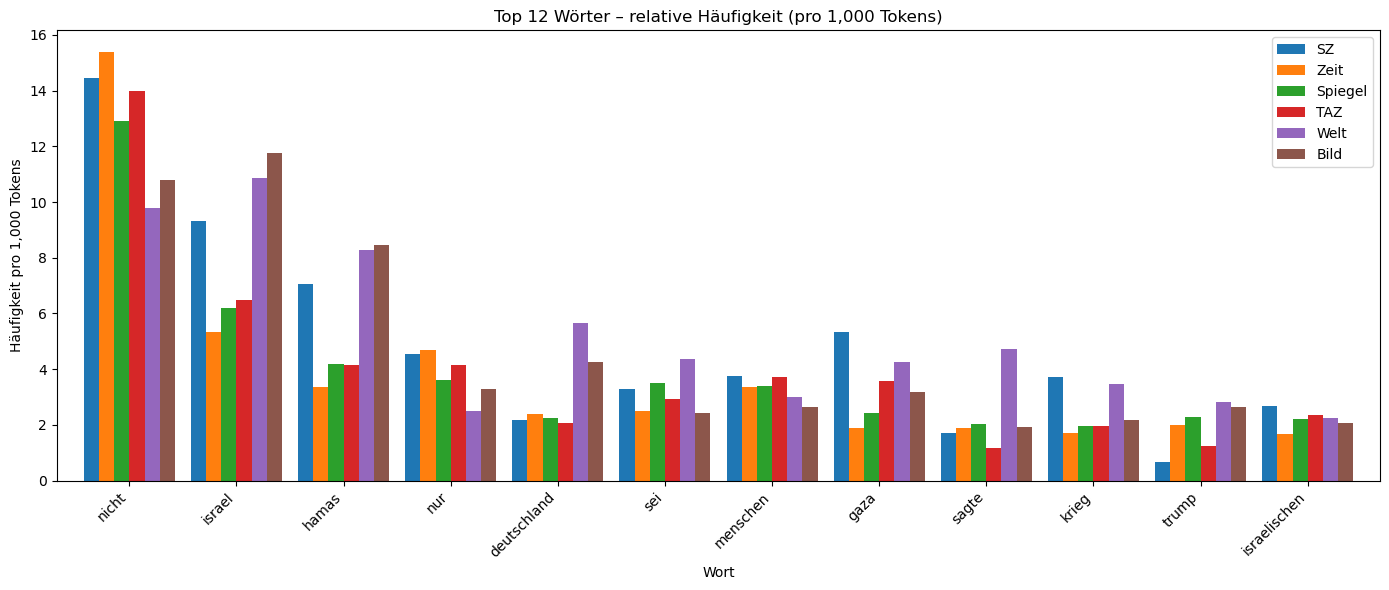


Top distinctive words per journal (delta vs mean of other journals):


,journal,word,delta_vs_others
2065494,Bild,israel,4.112493
2068574,Bild,bild,3.623139
1280265,TAZ,nen,3.455612
2065496,Bild,hamas,3.064747
1652396,Welt,israel,3.057651
...,...,...,...
833855,Spiegel,redaktion,0.313698
827907,Spiegel,offenbar,0.311602
826266,Spiegel,ihnen,0.299686
826845,Spiegel,hätten,0.293982


In [2]:
# =========================
# CONFIG
# =========================
BASE_DIR = Path("/home/arabella/Desktop/Journals")
# Example structure:
# /raw/
#   sz_txt/
#   faz_txt/
#   taz_txt/

JOURNAL_DIRS = {
    "SZ": BASE_DIR / "sz_txt",
     "Zeit": BASE_DIR / "diezeit_txt_clean",
     "Spiegel": BASE_DIR / "derspiegel_txt_clean",
    "TAZ": BASE_DIR / "taz_txt_clean",
    "Welt": BASE_DIR / "diewelt_txt_clean",
    "Bild": BASE_DIR / "bild_txt_clean"
}
MAX_FILES = None  # None = all
TOP_N = 12
NORM_PER = 1_000  # relative frequency: occurrences per 10,000 tokens

STOPWORDS = {
    "der", "die", "zeit", "das", "spiegel",
    "ein", "eine", "einer", "eines", "einem", "einen", "was",
    "und", "oder", "aber", "wenn", "dann", "denn", "dem", "für", "mit", "ohne",
    "gegen", "über", "unter", "zwischen", "hat",
    "zu", "zum", "zur", "von", "vom", "im", "in", "am", "an", "auf", "aus", "bei", "nach", "vor",
    "ist", "sind", "war", "waren", "sein", "wird", "werden", "wurde", "wurden", "gibt", "hier",
    "ich", "du", "er", "sie", "es", "wir", "ihr", "man", "den", "als", "sich", "des", "viele",
    "mich", "dich", "ihn", "uns", "euch", "seit", "nun", "haben", "will", "dort", "kann", "alle", "können",
    "mein", "meine", "dein", "deine", "seine", "ihre", "zwei", "durch", "immer", "wieder",
    "ja", "nein", "hatte", "seiner", "bis", "weil",
    "auch", "noch", "schon", "sehr", "mehr", "weniger", "so", "wie", "habe", "damit",
    "dass", "daß", "dies", "diese", "dieser", "dieses", "jener", "jene", "jenes",
    "online", "oktober"
}

def tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-zäöüß\s]", " ", text)
    words = text.split()
    return [w for w in words if w not in STOPWORDS and len(w) > 2]

def journal_word_counts(journal_dir: Path, max_files=None):
    files = sorted(journal_dir.glob("*.txt"))
    if max_files is not None:
        files = files[:max_files]

    all_words = []
    for txt_file in files:
        text = txt_file.read_text(encoding="utf-8", errors="ignore")
        all_words.extend(tokenize(text))

    counts = Counter(all_words)
    total_tokens = len(all_words)
    return counts, total_tokens, len(files)

def to_per_n(count, total_tokens, per=NORM_PER):
    if total_tokens == 0:
        return 0.0
    return (count / total_tokens) * per

def main():
    # --- compute counts per journal ---
    journal_counts = {}
    journal_tokens = {}
    journal_files = {}

    for jname, jdir in JOURNAL_DIRS.items():
        counts, total_tokens, nfiles = journal_word_counts(jdir, MAX_FILES)
        journal_counts[jname] = counts
        journal_tokens[jname] = total_tokens
        journal_files[jname] = nfiles
        print(f"{jname}: files={nfiles}, tokens(after cleaning)={total_tokens}")

    if not journal_counts:
        print("No journals configured. Fill JOURNAL_DIRS.")
        return

    # --- choose comparison vocabulary: top words across ALL journals combined ---
    global_counts = Counter()
    for jname, c in journal_counts.items():
        global_counts.update(c)

    top_words = [w for w, _ in global_counts.most_common(TOP_N)]

    # --- build a dataframe of relative frequencies ---
    rows = []
    for w in top_words:
        row = {"word": w}
        for jname in JOURNAL_DIRS.keys():
            row[jname] = to_per_n(journal_counts[jname].get(w, 0), journal_tokens[jname], NORM_PER)
        rows.append(row)

    df_plot = pd.DataFrame(rows).set_index("word")
    display(df_plot)

    # --- plot grouped bar chart ---
    ax = df_plot.plot(kind="bar", figsize=(14, 6), width=0.85)
    ax.set_title(f"Top {TOP_N} Wörter – relative Häufigkeit (pro {NORM_PER:,} Tokens)")
    ax.set_xlabel("Wort")
    ax.set_ylabel(f"Häufigkeit pro {NORM_PER:,} Tokens")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Optional: print most distinctive words per journal (difference vs mean of others)
    # (useful for “what stands out” rather than “most frequent overall”)
    distinct_rows = []
    for jname in JOURNAL_DIRS.keys():
        others = [o for o in JOURNAL_DIRS.keys() if o != jname]
        for w in global_counts.keys():
            v = to_per_n(journal_counts[jname].get(w, 0), journal_tokens[jname], NORM_PER)
            omean = np.mean([to_per_n(journal_counts[o].get(w, 0), journal_tokens[o], NORM_PER) for o in others]) if others else 0
            distinct_rows.append({"journal": jname, "word": w, "delta_vs_others": v - omean})

    distinct_df = pd.DataFrame(distinct_rows)
    top_distinct = distinct_df.sort_values("delta_vs_others", ascending=False).groupby("journal").head(15)
    print("\nTop distinctive words per journal (delta vs mean of other journals):")
    display(top_distinct)

if __name__ == "__main__":
    main()

In [3]:
# Cell 1: Setup + shared utilities
from pathlib import Path
import re
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse your JOURNAL_DIRS from previous notebook cell.
# Example expected:
# JOURNAL_DIRS = {
#    "SZ": Path("/.../sz_txt"),
#    "Zeit": Path("/.../diezeit_txt_clean"),
#    "Spiegel": Path("/.../derspiegel_txt_clean"),
#    "TAZ": Path("/.../taz_txt_clean"),
# }

# --- basic text helpers ---
TOKEN_RE = re.compile(r"[a-zäöüß\-]+", flags=re.IGNORECASE)

def normalize_text(s: str) -> str:
    s = s.lower()
    s = s.replace("ß", "ss")
    return s

def tokenize_simple(text: str):
    text = normalize_text(text)
    return TOKEN_RE.findall(text)

def split_sentences(text: str):
    # simple but effective for news text
    return re.split(r'(?<=[\.\!\?])\s+', text.strip())

def load_corpus(journal_dirs, max_files=None):
    """
    Returns:
      docs_df columns = [journal, file, text, tokens_n]
    """
    rows = []
    for jname, jdir in journal_dirs.items():
        files = sorted(Path(jdir).glob("*.txt"))
        if max_files is not None:
            files = files[:max_files]
        for fp in files:
            txt = fp.read_text(encoding="utf-8", errors="ignore")
            rows.append({
                "journal": jname,
                "file": fp.name,
                "text": txt,
                "tokens_n": len(tokenize_simple(txt))
            })
    docs_df = pd.DataFrame(rows)
    return docs_df

docs_df = load_corpus(JOURNAL_DIRS, max_files=None)
print(docs_df.groupby("journal")["file"].count())
print("Total docs:", len(docs_df))

journal
Bild        8170
SZ          2522
Spiegel     9190
TAZ         4629
Welt       15109
Zeit        6281
Name: file, dtype: int64
Total docs: 45901


,terror_frame,militant_frame,terror_frame_per_10k,militant_frame_per_10k,terror_vs_militant_ratio,log_terror_vs_militant,terror_share_in_pair
journal,,,,,,,
Bild,24076,1106,73.257911,3.365312,21.759150,3.080034,0.956062
SZ,5101,1133,24.163583,5.367053,4.500662,1.504224,0.818204
Spiegel,13001,3809,15.955765,4.674680,3.412915,1.227567,0.773392
TAZ,4402,1802,12.531603,5.129929,2.442441,0.892998,0.709508
Welt,42436,4786,41.988674,4.735550,8.865873,2.182209,0.898640
Zeit,9744,2392,12.593119,3.091414,4.072936,1.404364,0.802876


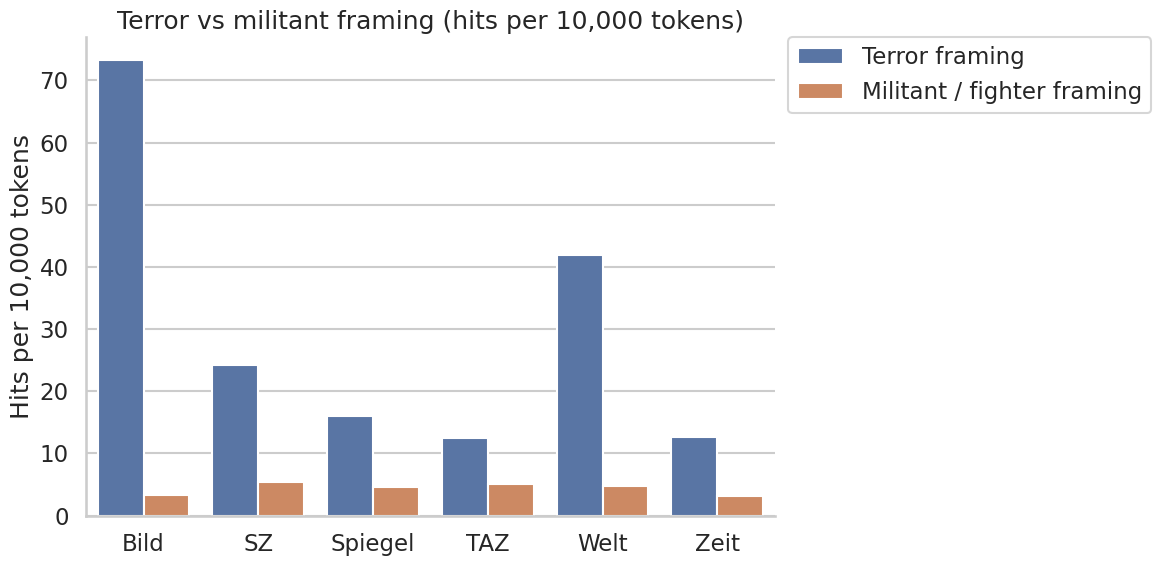

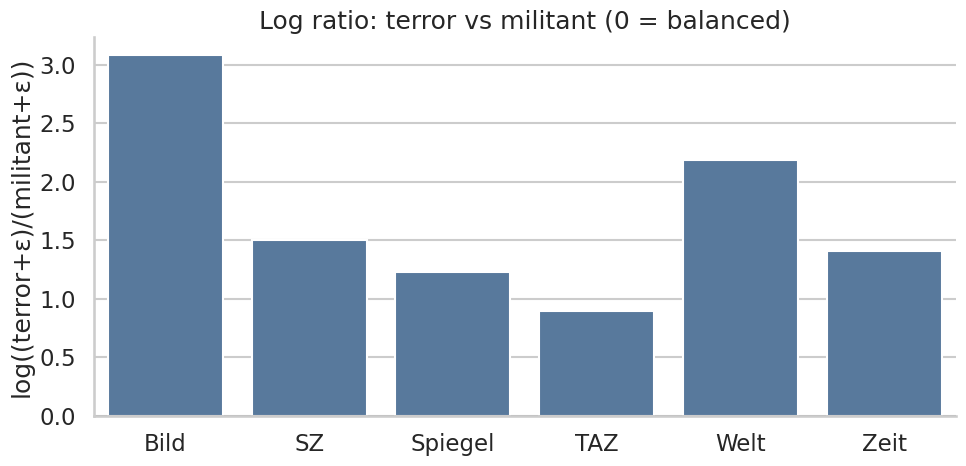

In [4]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# =========================
# CONFIG: only Terror vs Militant
# =========================
FRAME_SETS = {
    "terror_frame": [
        r"\bterror\w*\b", r"\bterrorismus\w*\b", r"\bterrorist\w*\b", r"\terrorgruppe\w*\b",r"\terrororganisation\w*\b",
        # optional expansions (uncomment if you want broader recall):
        # r"\banschlag\w*\b", r"\battentat\w*\b", r"\bislamist\w*\b", r"\bextremist\w*\b"
    ],
    "militant_frame": [
        r"\bmilitan\w*\b", r"\bkaempfer\w*\b", r"\bkämpfer\w*\b",
        r"\bbewaffnet\w*\b", r"\bbewaffnete\w*\b",
        # optional expansions:
        # r"\bmiliz\w*\b", r"\bparamilitär\w*\b"
    ],
}

FRAME_LABELS = {
    "terror_frame": "Terror framing",
    "militant_frame": "Militant / fighter framing",
    "terror_vs_militant_ratio": "Terror ÷ militant (ratio)",
    "log_terror_vs_militant": "Log ratio: terror vs militant",
    "terror_share_in_pair": "Terror share (terror + militant)",
}

compiled_frames = {
    k: [re.compile(p, flags=re.IGNORECASE) for p in pats]
    for k, pats in FRAME_SETS.items()
}

def count_frame_hits(text, regex_list):
    return sum(len(rx.findall(text)) for rx in regex_list)

# =========================
# Build per-doc counts
# docs_df must contain: journal, file, text, tokens_n
# =========================
rows = []
for _, r in docs_df.iterrows():
    t = r["text"]
    rec = {"journal": r["journal"], "file": r["file"], "tokens_n": r["tokens_n"]}
    for fname, regs in compiled_frames.items():
        rec[fname] = count_frame_hits(t, regs)
    rows.append(rec)

frame_df = pd.DataFrame(rows)

# =========================
# Aggregate by journal + normalize
# =========================
agg = frame_df.groupby("journal").sum(numeric_only=True)

for c in FRAME_SETS.keys():
    agg[f"{c}_per_10k"] = agg[c] / agg["tokens_n"] * 10000

eps = 0.5  # smoothing to avoid unstable ratios when one side is ~0
agg["terror_vs_militant_ratio"] = (agg["terror_frame"] + eps) / (agg["militant_frame"] + eps)
agg["log_terror_vs_militant"] = np.log((agg["terror_frame"] + eps) / (agg["militant_frame"] + eps))
agg["terror_share_in_pair"] = (agg["terror_frame"] + eps) / (agg["terror_frame"] + agg["militant_frame"] + 2 * eps)

display(agg[[
    "terror_frame", "militant_frame",
    "terror_frame_per_10k", "militant_frame_per_10k",
    "terror_vs_militant_ratio", "log_terror_vs_militant", "terror_share_in_pair"
]].sort_index())

# =========================
# Plot A: per-10k hits
# =========================
per10k_cols = ["terror_frame_per_10k", "militant_frame_per_10k"]
plot_per10k = agg[per10k_cols].reset_index().melt(id_vars="journal", var_name="frame", value_name="hits_per_10k")
plot_per10k["frame"] = plot_per10k["frame"].str.replace("_per_10k", "", regex=False)
plot_per10k["frame_label"] = plot_per10k["frame"].map(FRAME_LABELS)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=plot_per10k, x="journal", y="hits_per_10k", hue="frame_label")
ax.set_title("Terror vs militant framing (hits per 10,000 tokens)")
ax.set_xlabel("")
ax.set_ylabel("Hits per 10,000 tokens")
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
sns.despine()
plt.tight_layout()
plt.show()

# =========================
# Plot B: log ratio (diverging, easy comparison)
# =========================
ratio_plot = agg[["log_terror_vs_militant"]].reset_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=ratio_plot, x="journal", y="log_terror_vs_militant", color="#4C78A8")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Log ratio: terror vs militant (0 = balanced)")
ax.set_xlabel("")
ax.set_ylabel("log((terror+ε)/(militant+ε))")
sns.despine()
plt.tight_layout()
plt.show()

,israeli_official_per_10k,hamas_official_per_10k,gaza_health_ministry_per_10k,un_ngo_per_10k
journal,,,,
Bild,0.553786,1.214068,0.009128,0.225166
SZ,0.288959,0.914247,0.080529,0.464229
Spiegel,0.422182,1.725545,0.114136,0.454091
TAZ,0.270446,0.814184,0.054089,0.612061
Welt,0.634243,2.683412,0.136545,0.337405
Zeit,0.268819,0.832304,0.037480,0.297251


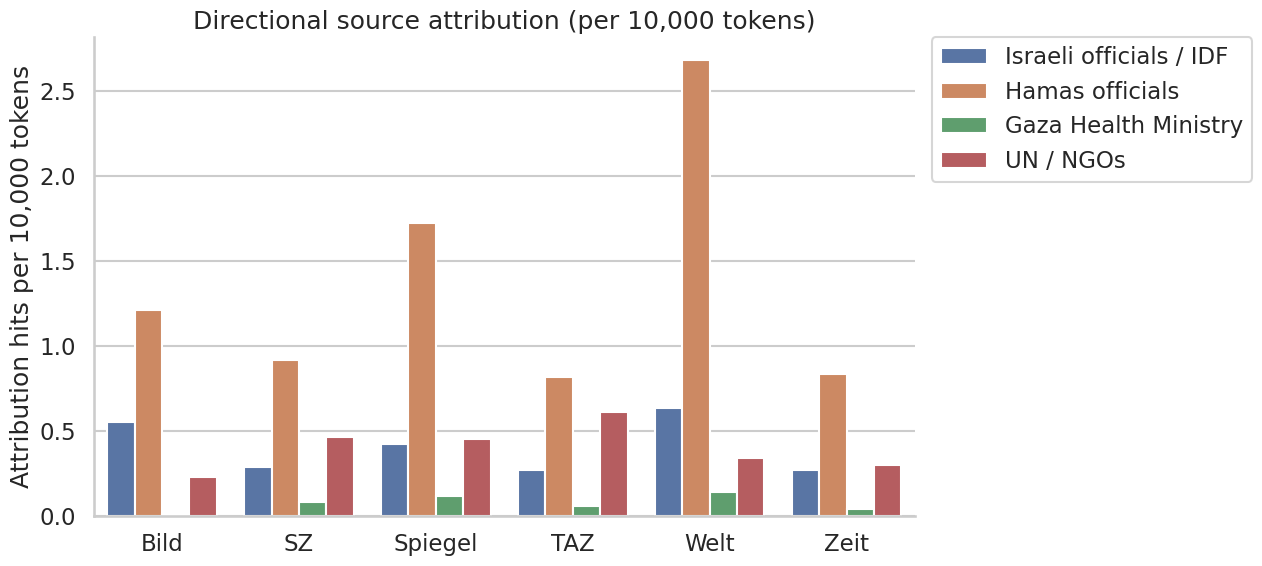


Snippets for: Israeli officials / IDF  (up to 10)

[1] SZ | 2023_10_07_antworten-auf-die-wichtigsten-fragen-zum-krieg.txt
teilte die armee mit. "die hamas hat heute morgen einen schweren fehler begangen", sagte verteidigungsminister joav gallant. wie auch ministerpräsident benjamin netanjahu betonte er: "wir werden diesen krieg gewinnen." <<die israelische armee teilte mit>>, es seien unter anderem 17 militäranlagen und vier kommandozentren der hamas angegriffen worden. laut palästinensischen angaben gibt es mindestens 232 tote und rund 1700 verletzte im gazastreifen. was hat es mit dem gaz

[2] SZ | 2023_10_08_israel-erlebt-einen-9-11-moment-wie-konnte-es-dazu-kommen.txt
durch tunnel zu verhindern . allein diese zusätzliche absicherung hat mehr als 500 millionen euro gekostet. der grenzzaun ist mit kameras, hightechsensoren und empfindlicher abhörtechnik ausgestattet. dieser zaun wurde <<nach angaben der israelischen armee>> an 29 stellen durchbrochen. ministerpräsident benjamin neta

In [7]:
# Cell 3: Test 2 - Source Attribution Balance (FIXED, minimal)
# - Directional patterns (reduce false positives, esp. Hamas)
# - Counts per 10k tokens per journal
# - 10 highlighted snippets per category for auditing
# - No balance/log-ratio plots or extra metrics

import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

def normalize_text(s: str) -> str:
    s = s.lower()
    s = s.replace("ß", "ss")
    return s

# -------------------------
# Directional attribution regexes (actor must be the SOURCE)
# -------------------------
SOURCE_ATTR_PATTERNS = {
    "israeli_official": [
        # "laut/nach Angaben ... IDF/israelisches Militär/Regierung"
        r"\b(?:laut|nach angaben|nach eigenen angaben)\b.{0,80}\b(?:idf|israelische(?:n|s|r)?\s+(?:streitkräfte|armee|militär)|israel\w*\s+(?:militär|armee|regierung))\b",
        # "die israelische armee/regierung teilte mit/erklärte/..."
        r"\bdie israelische(?:n|s|r)?\s+(?:armee|streitkräfte|regierung)\b.{0,80}\b(?:teilte\b.{0,10}\bmit|erklaerte|erklärte|meldete)\b",
        # Ministries / spokespersons
        r"\b(?:verteidigungsministerium|aussenministerium|außenministerium|regierungssprecher\w*)\b.{0,60}\bisrael\w*\b.{0,80}\b(?:teilte\b.{0,10}\bmit|erklaerte|erklärte)\b",
    ],

    # FIXED: Hamas must be subject/source (avoid "hamas ... , sagte scholz/faeser/..."):
    "hamas_official": [
        # Direct: "laut Hamas ..." / "nach Angaben der Hamas ..."
        r"\b(?:laut|nach angaben|nach eigenen angaben)\b.{0,60}\bder\s+hamas\b",
        r"\b(?:laut|nach angaben|nach eigenen angaben)\b.{0,60}\bhamas\b",

        # Spokesperson: "Hamas-Sprecher sagte/erklärte/teilte mit/verkündete ..."
        r"\bein(?:e[rnms])?\s+hamas[-\s]?sprecher\w*\b.{0,80}\b(?:sagte|erklaerte|erklärte|teilte\b.{0,10}\bmit|verkündete|verkuendete)\b",
        r"\bhamas[-\s]?sprecher\w*\b.{0,80}\b(?:sagte|erklaerte|erklärte|teilte\b.{0,10}\bmit|verkündete|verkuendete)\b",

        # Organization as subject: "Die Hamas erklärte/verkündete/teilte mit ..."
        r"\b(?:die|der|den|dem|des|eine|einer|einem|einen)\s+hamas\b.{0,80}\b(?:erklaerte|erklärte|verkündete|verkuendete|teilte\b.{0,10}\bmit)\b",

        # Slightly looser subject-like: "Hamas erklärte/verkündete/teilte mit ..." (NO 'sagte' here)
        r"\bhamas\b.{0,60}\b(?:erklaerte|erklärte|verkündete|verkuendete|teilte\b.{0,10}\bmit)\b",
    ],

    "gaza_health_ministry": [
        r"\b(?:laut|nach angaben|nach eigenen angaben)\b.{0,90}\b(?:gesundheitsministerium|gesundheitsbehoerd\w*|gesundheitsbehörd\w*)\b.{0,60}\b(?:gaza|gazastreifen)\b",
        r"\b(?:gesundheitsministerium|gesundheitsbehoerd\w*|gesundheitsbehörd\w*)\b.{0,60}\b(?:gaza|gazastreifen)\b.{0,80}\b(?:teilte\b.{0,10}\bmit|erklaerte|erklärte|hiess es|hieß es|sprach)\b",
    ],

    "un_ngo": [
        # avoid "un-plan" false positives
        r"\b(?:laut|nach angaben|nach eigenen angaben)\b.{0,90}\b(?:un\b(?!-plan)|uno|vereinte\s+nationen|unicef|unrwa|ocha|who|wfp|unhcr)\b",
        r"\b(?:laut|nach angaben|nach eigenen angaben)\b.{0,90}\b(?:amnesty|human rights watch|ikrk|rotes\s+kreuz|aerzte\s+ohne\s+grenzen|ärzte\s+ohne\s+grenzen|msf|save\s+the\s+children)\b",
        r"\b(?:un|uno)\s*-\s*sprecher\w*\b.{0,80}\b(?:sagte|erklaerte|erklärte|teilte\b.{0,10}\bmit)\b",
        r"\bun[-\s]?sprecher\w*\b.{0,80}\b(?:sagte|erklaerte|erklärte|teilte\b.{0,10}\bmit)\b",
    ],
}

SOURCE_LABELS = {
    "israeli_official": "Israeli officials / IDF",
    "hamas_official": "Hamas officials",
    "gaza_health_ministry": "Gaza Health Ministry",
    "un_ngo": "UN / NGOs",
}

compiled_sources = {
    k: [re.compile(p, flags=re.IGNORECASE | re.DOTALL) for p in pats]
    for k, pats in SOURCE_ATTR_PATTERNS.items()
}

def count_hits(text: str, regs) -> int:
    t = normalize_text(text)
    return sum(len(rx.findall(t)) for rx in regs)

def snippets_with_highlight(text: str, regs, max_snips=10, radius=200):
    """
    Returns snippets with matched span highlighted as <<...>>.
    """
    t = normalize_text(text)
    out = []
    for rx in regs:
        for m in rx.finditer(t):
            a = max(0, m.start() - radius)
            b = min(len(t), m.end() + radius)
            snippet = t[a:m.start()] + "<<" + t[m.start():m.end()] + ">>" + t[m.end():b]
            snippet = snippet.replace("\n", " ")
            snippet = re.sub(r"\s+", " ", snippet).strip()
            out.append(snippet)
            if len(out) >= max_snips:
                return out
    return out

# -------------------------
# Count per doc + collect snippets
# docs_df must contain: journal, file, tokens_n, text
# -------------------------
rows = []
snippet_bank = {k: [] for k in SOURCE_ATTR_PATTERNS.keys()}

for _, r in docs_df.iterrows():
    rec = {"journal": r["journal"], "file": r["file"], "tokens_n": r["tokens_n"]}
    text = r["text"]

    for sname, regs in compiled_sources.items():
        rec[sname] = count_hits(text, regs)

        if len(snippet_bank[sname]) < 10:
            need = 10 - len(snippet_bank[sname])
            snips = snippets_with_highlight(text, regs, max_snips=need, radius=220)
            for sn in snips:
                snippet_bank[sname].append({"journal": r["journal"], "file": r["file"], "snippet": sn})

    rows.append(rec)

src_df = pd.DataFrame(rows)
src_agg = src_df.groupby("journal").sum(numeric_only=True)

for c in SOURCE_ATTR_PATTERNS.keys():
    src_agg[f"{c}_per_10k"] = src_agg[c] / src_agg["tokens_n"] * 10000

# Show table
display_cols = [f"{c}_per_10k" for c in SOURCE_ATTR_PATTERNS.keys()]
display(src_agg[display_cols].sort_index())

# -------------------------
# Plot: per-10k attribution hits (nice)
# -------------------------
plot_df = src_agg[display_cols].reset_index().melt(
    id_vars="journal", var_name="source", value_name="hits_per_10k"
)
plot_df["source"] = plot_df["source"].str.replace("_per_10k", "", regex=False)
plot_df["source_label"] = plot_df["source"].map(SOURCE_LABELS)

plt.figure(figsize=(13, 6))
ax = sns.barplot(data=plot_df, x="journal", y="hits_per_10k", hue="source_label")
ax.set_title("Directional source attribution (per 10,000 tokens)")
ax.set_xlabel("")
ax.set_ylabel("Attribution hits per 10,000 tokens")
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
sns.despine()
plt.tight_layout()
plt.show()

# -------------------------
# Print snippets (auditing)
# -------------------------
for sname in SOURCE_ATTR_PATTERNS.keys():
    print("\n" + "=" * 80)
    print(f"Snippets for: {SOURCE_LABELS.get(sname, sname)}  (up to 10)")
    got = snippet_bank[sname]
    if not got:
        print("No snippets found.")
        continue
    for i, item in enumerate(got, 1):
        print(f"\n[{i}] {item['journal']} | {item['file']}")
        print(item["snippet"])

In [18]:
# Expanded Test 1: Harm Event Extraction (HUMAN AUDIT CSV)
# Output columns (in this order):
#   file | sentence | journal | perpetrator | target | attribution | primary_event
# No triggered-category counts, no one-hot columns, no summary tables.

import re
import pandas as pd

# ---------------------------
# Helpers
# ---------------------------
def normalize_text(s: str) -> str:
    return s.lower().replace("ß", "ss")

def split_sentences(text: str):
    return re.split(r'(?<=[\.\!\?])\s+', text.strip())

def compile_dict(d):
    return {k: [re.compile(p, flags=re.IGNORECASE) for p in pats] for k, pats in d.items()}

def find_matches(rx_dict, text):
    out = []
    for label, regs in rx_dict.items():
        if any(rx.search(text) for rx in regs):
            out.append(label)
    return out

def join_labels(labels, fallback):
    if not labels:
        return fallback
    # stable + readable: dedupe + sort + join
    return "; ".join(sorted(set(labels)))

def pick_primary_event(events):
    """
    Choose a single primary event to make manual review easier.
    Priority order can be adjusted.
    """
    priority = [
        "killing",
        "injury_maiming",
        "arrest_detention",
        "disappearance"
    ]
    if not events:
        return "none"
    for p in priority:
        if p in events:
            return p
    return events[0]

# ---------------------------
# Event dictionaries
# ---------------------------
EVENT_PATTERNS = {
    "killing": [
        r"\b(getoetet|getötet|erschossen|umgebracht|toedlich|tödlich|starb|gestorben|tot)\b"
    ],
    "injury_maiming": [
        r"\b(verletzt|verwundet|verstummelt|verstümmelt)\b"
    ],
    "arrest_detention": [
        r"\b(festgenommen|verhaftet|inhaftiert|in haft|festgehalten|detention)\b"
    ],
    "disappearance": [
        r"\b(verschwunden|zwangsverschwinden|enforced disappearance|verschleppt)\b"
    ]
}

TARGET_PATTERNS = {
    "journalist_media_worker": [
        r"\b(journalist\w*|reporter\w*|fotograf\w*|kameramann|korrespondent\w*|medienarbeiter\w*|pressevertreter\w*)\b"
    ],
    "media_institution": [
        r"\b(redaktion\w*|sender\w*|medienhaus|agentur|nachrichtenbuero|nachrichtenbüro|pressebuero|pressebüro|studio)\b"
    ],
    "family_member": [
        r"\b(familie|angehoerig\w*|angehörig\w*|kind\w*|ehefrau|ehemann)\b"
    ],
}

# --- add to TARGET_PATTERNS ---
TARGET_PATTERNS.update({
    "palestinian_people": [
        r"\bpalastinens\w*\b", r"\bpalästinens\w*\b", r"\bgaza\w*\b"
    ],
    "israeli_people": [
        r"\bisraelis?\b", r"\bisraelisch\w* zivil\w*\b"
    ],
    "generic_civilians": [
        r"\b(zivilist\w*|menschen|personen|opfer|bevoelkerung|bevölkerung)\b"
    ]
})

# ---------------------------
# Expanded perpetrator schema
# ---------------------------
PERPETRATOR_PATTERNS = {
    "israeli_state_forces": [
        r"\b(idf|israelisch\w* (armee|militaer|militär|streitkraefte|streitkräfte|soldat\w*|luftwaffe)|israelische\w* (kraefte|kräfte|polizei|geheimdienst\w*)|shin bet)\b"
    ],
    "palestinian_armed_groups": [
        r"\b(hamas|qassam|islamischer dschihad|palestinian islamic jihad|pij|al[-\s]?qassam|bewaffnete palastinensische gruppen|bewaffnete palästinensische gruppen)\b"
    ],
    "israeli_settlers": [
        r"\b(siedler\w*|israelische\w* siedler\w*|settler\w*)\b"
    ],
    "other_state_or_foreign_forces": [
        r"\b(aegyptisch\w* kraefte|ägyptisch\w* kräfte|us[-\s]?militaer|us[-\s]?militär|iranisch\w* kraefte|huthi\w*|hezbollah)\b"
    ],
    "civilian_mob_or_unknown_gunmen": [
        r"\b(unbekannte bewaffnete|bewaffnete maenner|bewaffnete männer|mob|lynch)\b"
    ],
}

# --- add to PERPETRATOR_PATTERNS ---
PERPETRATOR_PATTERNS.update({
    "security_forces_generic": [
        r"\bsicherheitskraefte\b", r"\bsicherheitskräfte\b", r"\bmilitaer\b", r"\bmilitär\b"
    ],
    "attackers_unspecified": [
        r"\b(bombenanschlag|anschlag|attentat|raketenangriff|beschuss)\b",
        r"\b(entfuehrt|entführt)\b"
    ]
})

# ---------------------------
# Attribution/source schema (keep, but only export labels; you said you'll verify manually)
# ---------------------------
ATTRIBUTION_PATTERNS = {
    "according_to_israeli_officials": [
        r"\b(laut|nach angaben von)\b.{0,60}\b(idf|israel\w* (armee|regierung|militaer|militär|polizei)|sprecher\w* der israel\w*)\b"
    ],
    "according_to_palestinian_officials_or_groups": [
        r"\b(laut|nach angaben von)\b.{0,60}\b(hamas|gesundheitsministerium\w*.*gaza|palastinens\w* behoerden|palästinens\w* behörden)\b"
    ],
    "according_to_un_ngo_intl": [
        r"\b(laut|nach angaben von)\b.{0,60}\b(un|vereinte nationen|unrwa|amnesty|human rights watch|ikrk|rotes kreuz|cpj|rsf|reporter ohne grenzen)\b",
        r"\bnach angaben der vereinten nationen\b",
        r"\blaut einem bericht der vereinten nationen\b",
    ],
    "according_to_witnesses": [
        r"\b(laut|nach)\b.{0,40}\b(zeugen|augenzeugen|witnesses)\b"
    ]
}

# ---------------------------
# Compile regexes
# ---------------------------
EVENT_RX  = compile_dict(EVENT_PATTERNS)
TARGET_RX = compile_dict(TARGET_PATTERNS)
PERP_RX   = compile_dict(PERPETRATOR_PATTERNS)
ATTR_RX   = compile_dict(ATTRIBUTION_PATTERNS)

# ---------------------------
# Extract (human-audit table)
# ---------------------------
audit_rows = []

for _, doc in docs_df.iterrows():
    journal = doc["journal"]
    file_ = doc["file"]

    for sent in split_sentences(doc["text"]):
        sentence = sent.strip()
        if len(sentence) < 20:
            continue

        s = normalize_text(sentence)

        events = find_matches(EVENT_RX, s)
        if not events:
            continue

        targets = find_matches(TARGET_RX, s)
        perps   = find_matches(PERP_RX, s)
        attrs   = find_matches(ATTR_RX, s)

        # Post-processing similar to your original, but exported as readable strings
        if not perps:
            perps_out = "unspecified_perpetrator"
        else:
            perps_out = join_labels(perps, "unspecified_perpetrator")
            if len(set(perps)) > 1:
                perps_out = perps_out + "; multiple_or_disputed_perpetrator_mentions"

        targets_out = join_labels(targets, "unspecified_target")
        attrs_out   = join_labels(attrs, "no_explicit_attribution")
        primary_event = pick_primary_event(events)

        audit_rows.append({
            "file": file_,
            "sentence": sentence,
            "journal": journal,
            "perpetrator": perps_out,
            "target": targets_out,
            "attribution": attrs_out,
            "primary_event": primary_event,
        })

audit_df = pd.DataFrame(audit_rows)

# EXACT column order requested
audit_df = audit_df[[
    "file",
    "sentence",
    "journal",
    "perpetrator",
    "target",
    "attribution",
    "primary_event"
]]

print("Extracted event sentences:", len(audit_df))
display(audit_df.head(20))

# Optional: sort to make manual review easier
audit_df = audit_df.sort_values(["journal", "file"]).reset_index(drop=True)

# Save a single clean audit CSV
out_path = "harm_event_sentences_human_audit.csv"
audit_df.to_csv(out_path, index=False, encoding="utf-8")
print(f"Saved: {out_path}")

Extracted event sentences: 37966


,file,sentence,journal,perpetrator,target,attribution,primary_event
0,2023_10_07_antworten-auf-die-wichtigsten-frage...,Mindestens 200 Israelis starben bei den Angrif...,SZ,unspecified_perpetrator,israeli_people,no_explicit_attribution,injury_maiming
1,2023_10_07_chronologie-eines-schier-endlosen-k...,"Tausende Menschen sind gestorben, etliche Bemü...",SZ,unspecified_perpetrator,generic_civilians,no_explicit_attribution,killing
2,2023_10_07_chronologie-eines-schier-endlosen-k...,Juli 2014Wieder Spannungen zwischen Gaza und I...,SZ,attackers_unspecified,palestinian_people,no_explicit_attribution,killing
3,2023_10_07_chronologie-eines-schier-endlosen-k...,"Auf beiden Seiten sterben mehrere Menschen, Hu...",SZ,unspecified_perpetrator,generic_civilians,no_explicit_attribution,injury_maiming
4,2023_10_07_chronologie-eines-schier-endlosen-k...,Bei einem Bombenanschlag in Jerusalem stirbt e...,SZ,attackers_unspecified,generic_civilians,no_explicit_attribution,injury_maiming
5,2023_10_07_chronologie-eines-schier-endlosen-k...,Nach Angaben der Vereinten Nationen werden bis...,SZ,unspecified_perpetrator,israeli_people; palestinian_people,according_to_un_ngo_intl,killing
6,2023_10_07_chronologie-eines-schier-endlosen-k...,Bis August werden laut einem Bericht der Verei...,SZ,unspecified_perpetrator,israeli_people; palestinian_people,according_to_un_ngo_intl,killing
7,2023_10_08_der-meister-der-m-rtyrer.txt,Nun haben israelische Streitkräfte den meistge...,SZ,israeli_state_forces,unspecified_target,no_explicit_attribution,killing
8,2023_10_08_der-meister-der-m-rtyrer.txt,Als Chef der Islamisten-Hochburg am Mittelmeer...,SZ,unspecified_perpetrator,unspecified_target,no_explicit_attribution,killing
9,2023_10_08_der-meister-der-m-rtyrer.txt,Für die Ermordung zweier israelischer Soldaten...,SZ,israeli_state_forces,palestinian_people,no_explicit_attribution,killing


Saved: harm_event_sentences_human_audit.csv


In [8]:
criteria_text = """
CSV SCHEMA + CODING CRITERIA
============================

File purpose
------------
This CSV contains sentence-level extractions from newspaper text for event coding related to harms against journalists/media ecosystem and related conflict reporting.

Unit of analysis
----------------
- One row = one sentence that matched at least one EVENT pattern.

Column definitions
------------------

journal
- Outlet label from JOURNAL_DIRS key (e.g., SZ, Zeit, Spiegel, TAZ).

file
- Source text filename.

sentence
- Original sentence text (as split by regex sentence splitter).

events
- List of matched EVENT categories.
- A sentence may contain multiple event labels.

targets
- List of matched target categories (who is affected).
- If no target pattern is found, value is ['unspecified_target'].

perpetrators
- List of matched perpetrator categories (who allegedly committed the act).
- If no perpetrator pattern is found, value is ['unspecified_perpetrator'].
- If multiple perpetrator categories matched, list may include multiple labels.

attributions
- List of matched source-attribution categories (e.g., 'according_to_un_ngo_intl').
- If no explicit attribution pattern is found, value is ['no_explicit_attribution'].

event__<label>  (optional one-hot columns)
- Binary indicator (0/1) that event label is present in the row.

primary_event (optional)
- First event label in the matched events list (or 'none' if empty).

Event category criteria
-----------------------
killing
- Terms indicating death/homicide (e.g., getötet, erschossen, tot, gestorben).

injury_maiming
- Terms indicating injury/wounding/mutilation.

arrest_detention
- Terms indicating arrest, detention, imprisonment.

disappearance
- Terms indicating disappearance/abduction where fate/location is unknown.

threat_harassment
- Terms indicating threat/intimidation/harassment (depending on pattern constraints).

infrastructure_destruction
- Attack/destruction/disruption references tied to media/telecom infrastructure.

equipment_confiscation
- Confiscation/seizure/removal of journalistic equipment.

foreign_press_exclusion
- Exclusion/expulsion/access denial of foreign journalists/press.

label_terrorist_or_hamas
- Statements labeling journalists/media workers as terrorist/Hamas-fighter etc.

family_targeting
- Harm/threat/arrest language targeting family members.

Target category criteria
------------------------
journalist_media_worker
- Mentions of journalists/reporters/photojournalists/correspondents/media workers.

media_institution
- Mentions of newsroom/media house/agency/studio/press office.

family_member
- Mentions of family/relatives/spouse/children.

generic_civilians / palestinian_people / israeli_people (if enabled)
- Broader civilian identity group mentions.

Perpetrator category criteria
-----------------------------
israeli_state_forces
- IDF, Israeli military/police/security/intelligence references.

palestinian_armed_groups
- Hamas/PIJ/Qassam/related armed group references.

israeli_settlers
- Settler actor references.

other_state_or_foreign_forces
- Other named state/non-local armed actors.

attackers_unspecified / civilian_mob_or_unknown_gunmen
- Generic attacker descriptions without clear institutional actor.

unspecified_perpetrator
- No perpetrator cue detected in sentence.

Attribution category criteria
-----------------------------
according_to_israeli_officials
according_to_palestinian_officials_or_groups
according_to_un_ngo_intl
according_to_witnesses
no_explicit_attribution

Method limitations
------------------
- Regex-based matching: sensitive to wording and may miss paraphrases.
- Sentence-level scope: cross-sentence coreference may be missed.
- Categories indicate textual mention patterns, not legal findings.
- Manual validation is required before substantive claims.
"""

with open("coding_criteria.txt", "w", encoding="utf-8") as f:
    f.write(criteria_text.strip() + "\n")

print("Saved coding_criteria.txt")

Saved coding_criteria.txt


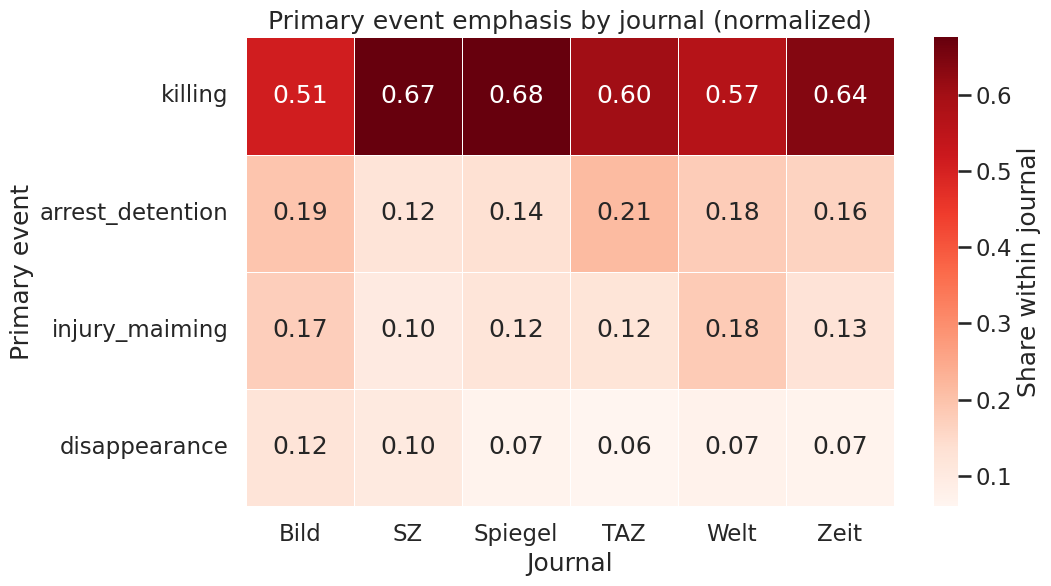

/tmp/ipykernel_98181/2495364472.py:223: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.80)


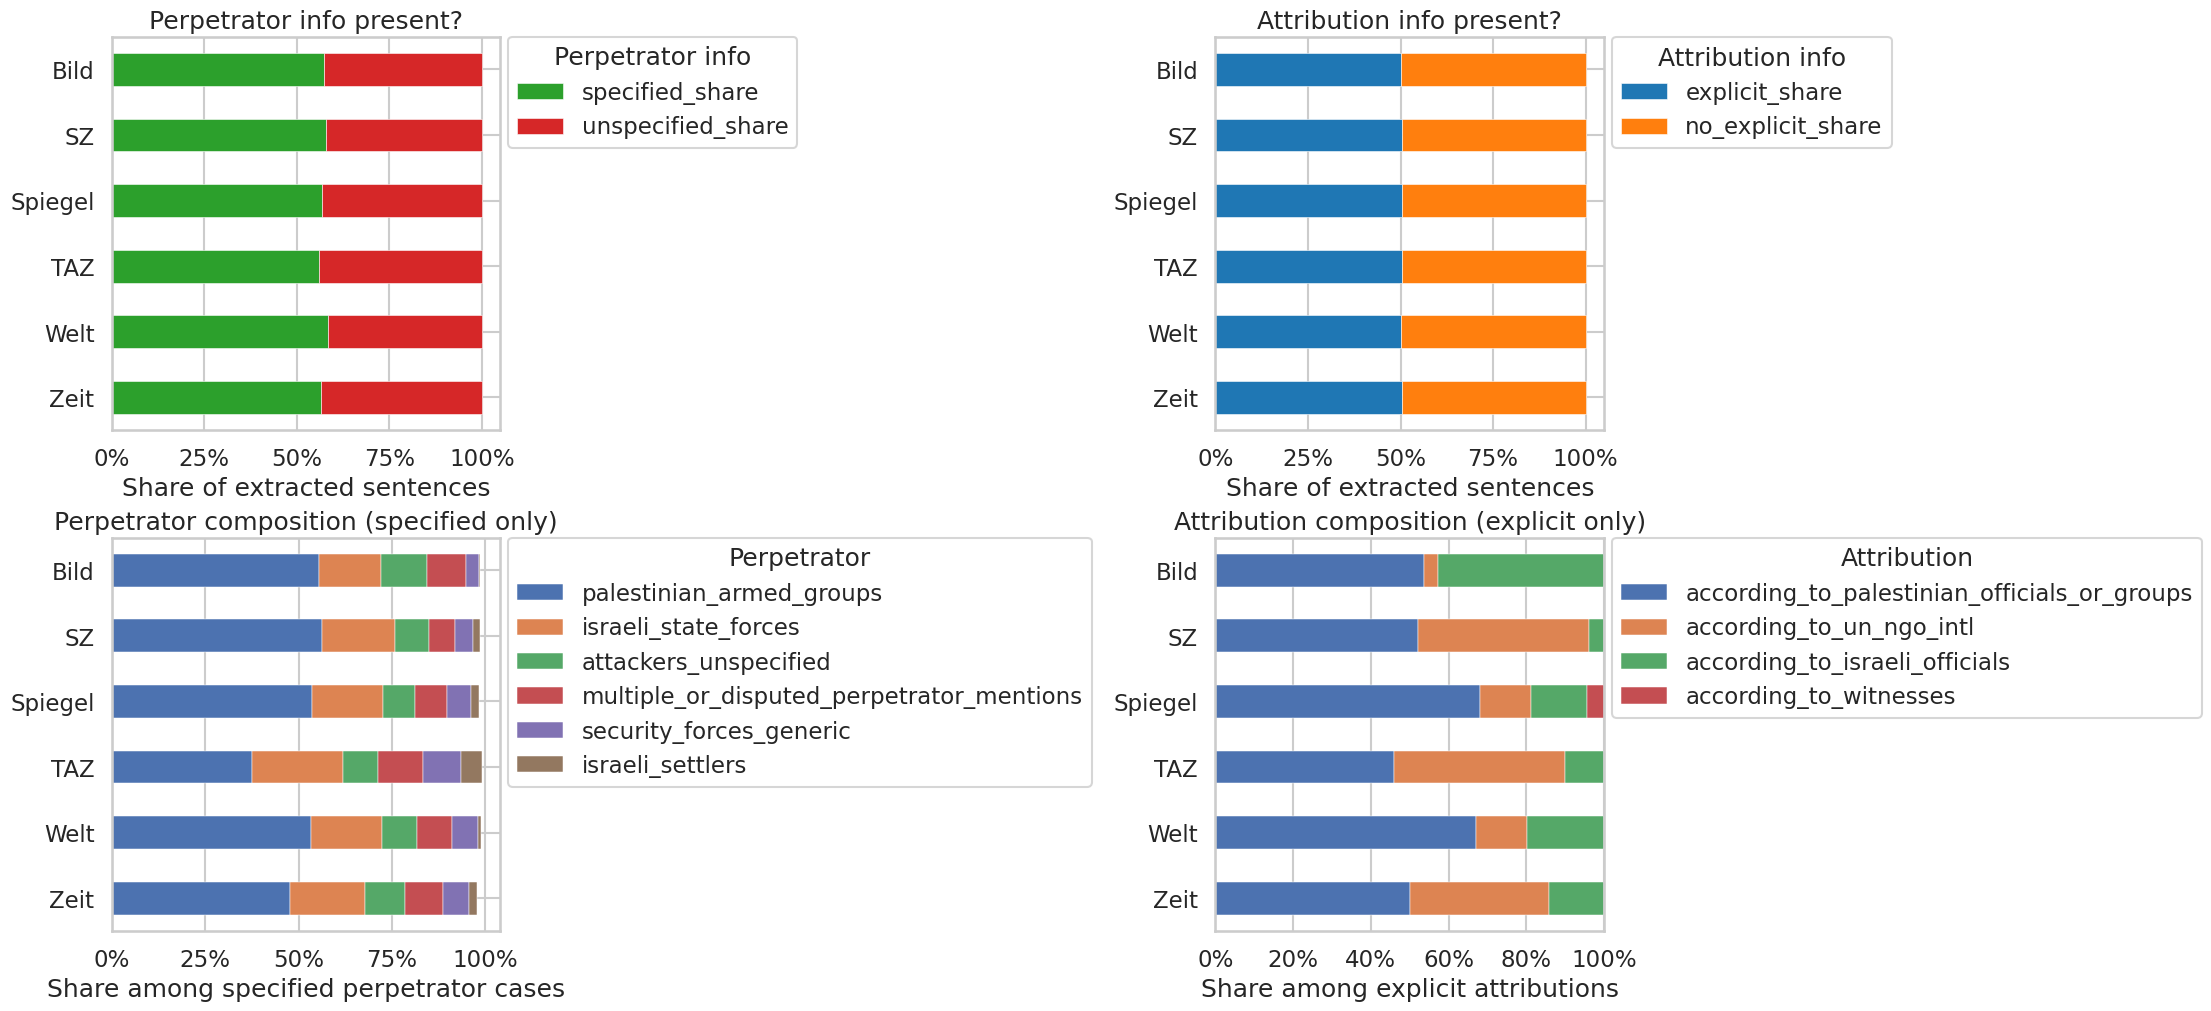

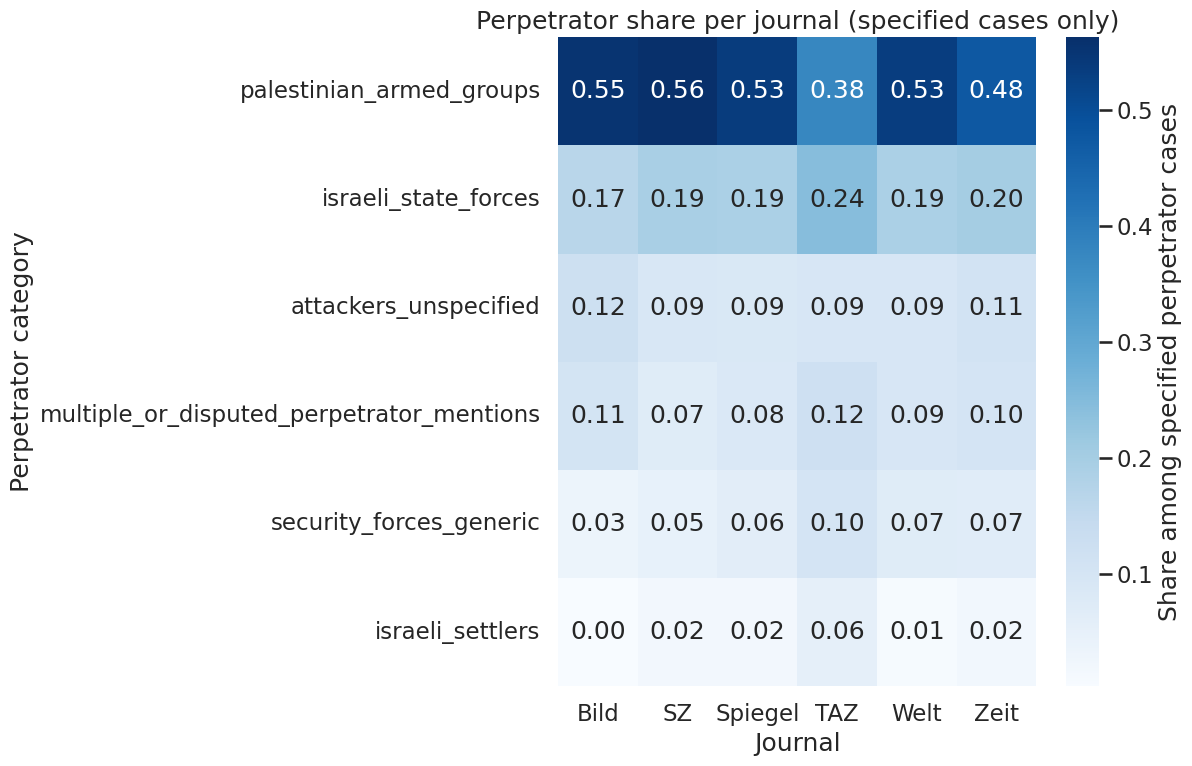

In [19]:
# Cell: Test 1 visualizations (for audit_df)
# - FIGURE 1A: primary_event heatmap (standalone, roomy)
# - FIGURE 1B: 4-panel dashboard (horizontal bar charts, legends outside)
# - FIGURE 2: perpetrator share heatmap (specified only) — kept like before

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid", context="talk")

# ---------------------------
# Helpers
# ---------------------------
def explode_str_labels(df, col, sep="; "):
    """
    Explode a column that contains:
      - a single label string, or
      - multiple labels joined by '; '.
    Returns counts by journal + label.
    """
    tmp = df[["journal", col]].copy()
    tmp[col] = tmp[col].fillna("").astype(str)
    tmp[col] = tmp[col].apply(lambda x: [p.strip() for p in x.split(sep) if p.strip()] if x else [])
    return (
        tmp.explode(col)
           .query(f"{col} != ''")
           .groupby(["journal", col]).size()
           .rename("n")
           .reset_index()
    )

def share_within_journal(mat):
    # normalize each journal column to sum=1
    return mat.div(mat.sum(axis=0).replace(0, np.nan), axis=1).fillna(0)

def share_within_row(mat):
    # normalize each journal row to sum=1
    return mat.div(mat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

def top_n_columns_by_total(mat, n=6):
    return mat.sum(axis=0).sort_values(ascending=False).head(n).index.tolist()

def legend_outside(ax, title=None):
    ax.legend(
        title=title if title is not None else "",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.0,
        frameon=True
    )

# Optional: shorten journal names in bar charts (does not affect heatmaps)
JOURNAL_LABELS = {
    "Sueddeutsche": "SZ",
    "Süddeutsche": "SZ",
    "Sueddeutsche Zeitung": "SZ",
    "Süddeutsche Zeitung": "SZ",
    "Die Zeit": "Zeit",
    "Zeit": "Zeit",
    "Der Spiegel": "Spiegel",
    "Spiegel": "Spiegel",
}

def map_journal_index(df):
    df = df.copy()
    df.index = [JOURNAL_LABELS.get(j, j) for j in df.index]
    return df

# ---------------------------
# 1) Primary event heatmap (from audit_df.primary_event)
# ---------------------------
event_counts = (
    audit_df.groupby(["journal", "primary_event"]).size()
            .rename("n").reset_index()
)
event_mat = event_counts.pivot(index="primary_event", columns="journal", values="n").fillna(0)
event_mat_colnorm = share_within_journal(event_mat)

# order event rows by overall prevalence
event_order = event_mat.sum(axis=1).sort_values(ascending=False).index
event_mat_colnorm = event_mat_colnorm.loc[event_order]

# ---------------------------
# 2) Perpetrator quality + composition among specified only
# ---------------------------
perp_counts = explode_str_labels(audit_df, "perpetrator")
perp_mat = perp_counts.pivot(index="journal", columns="perpetrator", values="n").fillna(0)

unspec_perp_cols = [c for c in perp_mat.columns if "unspecified_perpetrator" in c.lower()]
if not unspec_perp_cols:
    perp_mat["unspecified_perpetrator"] = 0
    unspec_perp_cols = ["unspecified_perpetrator"]

perp_mat["unspecified_total"] = perp_mat[unspec_perp_cols].sum(axis=1)
perp_mat["total"] = perp_mat.sum(axis=1)

perp_quality = pd.DataFrame(index=perp_mat.index)
perp_quality["specified_share"] = (perp_mat["total"] - perp_mat["unspecified_total"]) / perp_mat["total"].replace(0, np.nan)
perp_quality["unspecified_share"] = perp_mat["unspecified_total"] / perp_mat["total"].replace(0, np.nan)
perp_quality = perp_quality.fillna(0)

# specified-only composition (exclude unspecified buckets + helper totals)
perp_spec_cols = [c for c in perp_mat.columns if c not in (unspec_perp_cols + ["unspecified_total", "total"])]
perp_spec = perp_mat[perp_spec_cols].copy()
perp_spec_share = share_within_row(perp_spec)

top_perp_spec = top_n_columns_by_total(perp_spec, n=6)
perp_spec_share_plot = perp_spec_share[top_perp_spec]

# ---------------------------
# 3) Attribution quality + composition among explicit only
# ---------------------------
attr_counts = explode_str_labels(audit_df, "attribution")
attr_mat = attr_counts.pivot(index="journal", columns="attribution", values="n").fillna(0)

no_attr_cols = [c for c in attr_mat.columns if "no_explicit_attribution" in c.lower()]
if not no_attr_cols:
    attr_mat["no_explicit_attribution"] = 0
    no_attr_cols = ["no_explicit_attribution"]

attr_mat["no_attr_total"] = attr_mat[no_attr_cols].sum(axis=1)
attr_mat["total"] = attr_mat.sum(axis=1)

attr_quality = pd.DataFrame(index=attr_mat.index)
attr_quality["explicit_share"] = (attr_mat["total"] - attr_mat["no_attr_total"]) / attr_mat["total"].replace(0, np.nan)
attr_quality["no_explicit_share"] = attr_mat["no_attr_total"] / attr_mat["total"].replace(0, np.nan)
attr_quality = attr_quality.fillna(0)

attr_exp_cols = [c for c in attr_mat.columns if c not in (no_attr_cols + ["no_attr_total", "total"])]
attr_exp = attr_mat[attr_exp_cols].copy()
attr_exp_share = share_within_row(attr_exp)

top_attr_exp = top_n_columns_by_total(attr_exp, n=6)
attr_exp_share_plot = attr_exp_share[top_attr_exp]

# -------------------------------------------------------------------
# FIGURE 1A: Event heatmap (standalone, roomy)
# -------------------------------------------------------------------
plt.figure(figsize=(11, 0.55 * len(event_mat_colnorm.index) + 4))
ax = sns.heatmap(
    event_mat_colnorm,
    cmap="Reds",
    annot=True, fmt=".2f",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Share within journal"},
)
ax.set_title("Primary event emphasis by journal (normalized)")
ax.set_xlabel("Journal")
ax.set_ylabel("Primary event")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# FIGURE 1B: 4-panel dashboard (horizontal bars)
# -------------------------------------------------------------------
perp_quality_p = map_journal_index(perp_quality)
attr_quality_p = map_journal_index(attr_quality)
perp_spec_share_plot_p = map_journal_index(perp_spec_share_plot)
attr_exp_share_plot_p = map_journal_index(attr_exp_share_plot)

fig, axes = plt.subplots(2, 2, figsize=(22, 10), constrained_layout=True)

# B) Perpetrator quality
ax = axes[0, 0]
perp_quality_p[["specified_share", "unspecified_share"]].plot(
    kind="barh", stacked=True, ax=ax,
    color=["#2ca02c", "#d62728"],
    edgecolor="white", linewidth=0.4, legend=False
)
ax.set_title("Perpetrator info present?")
ax.set_xlabel("Share of extracted sentences")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("")
ax.invert_yaxis()
legend_outside(ax, title="Perpetrator info")

# C) Attribution quality
ax = axes[0, 1]
attr_quality_p[["explicit_share", "no_explicit_share"]].plot(
    kind="barh", stacked=True, ax=ax,
    color=["#1f77b4", "#ff7f0e"],
    edgecolor="white", linewidth=0.4, legend=False
)
ax.set_title("Attribution info present?")
ax.set_xlabel("Share of extracted sentences")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("")
ax.invert_yaxis()
legend_outside(ax, title="Attribution info")

# D) Perpetrator composition among specified only
ax = axes[1, 0]
perp_spec_share_plot_p.plot(
    kind="barh", stacked=True, ax=ax,
    edgecolor="white", linewidth=0.35, legend=False
)
ax.set_title("Perpetrator composition (specified only)")
ax.set_xlabel("Share among specified perpetrator cases")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("")
ax.invert_yaxis()
legend_outside(ax, title="Perpetrator")

# E) Attribution composition among explicit only
ax = axes[1, 1]
attr_exp_share_plot_p.plot(
    kind="barh", stacked=True, ax=ax,
    edgecolor="white", linewidth=0.35, legend=False
)
ax.set_title("Attribution composition (explicit only)")
ax.set_xlabel("Share among explicit attributions")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("")
ax.invert_yaxis()
legend_outside(ax, title="Attribution")

# reserve room for outside legends
fig.subplots_adjust(right=0.80)
plt.show()

# -------------------------------------------------------------------
# FIGURE 2: Perpetrator share heatmap (specified cases only) — kept like before
# -------------------------------------------------------------------
plt.figure(figsize=(12, 8))
sns.heatmap(
    perp_spec_share_plot.T,  # perpetrators as rows for readability
    annot=True, fmt=".2f", cmap="Blues",
    cbar_kws={"label": "Share among specified perpetrator cases"}
)
plt.title("Perpetrator share per journal (specified cases only)")
plt.xlabel("Journal")
plt.ylabel("Perpetrator category")
plt.tight_layout()
plt.show()

Target counts by journal:


target,family_member,generic_civilians,israeli_people,journalist_media_worker,media_institution,palestinian_people,unspecified_target
journal,,,,,,,
Bild,295,879,113,24,20,764,2789
SZ,225,547,80,42,16,604,1127
Spiegel,707,2860,181,156,45,2262,5042
TAZ,280,790,72,115,18,651,1873
Welt,662,3698,237,175,88,3150,5897
Zeit,370,1603,87,99,18,955,3477


Target shares within journal:


target,family_member,generic_civilians,israeli_people,journalist_media_worker,media_institution,palestinian_people,unspecified_target
journal,,,,,,,
Bild,6.04,18.00,2.31,0.49,0.41,15.64,57.10
SZ,8.52,20.71,3.03,1.59,0.61,22.87,42.67
Spiegel,6.28,25.42,1.61,1.39,0.40,20.10,44.81
TAZ,7.37,20.79,1.90,3.03,0.47,17.14,49.30
Welt,4.76,26.59,1.70,1.26,0.63,22.65,42.40
Zeit,5.60,24.25,1.32,1.50,0.27,14.45,52.61


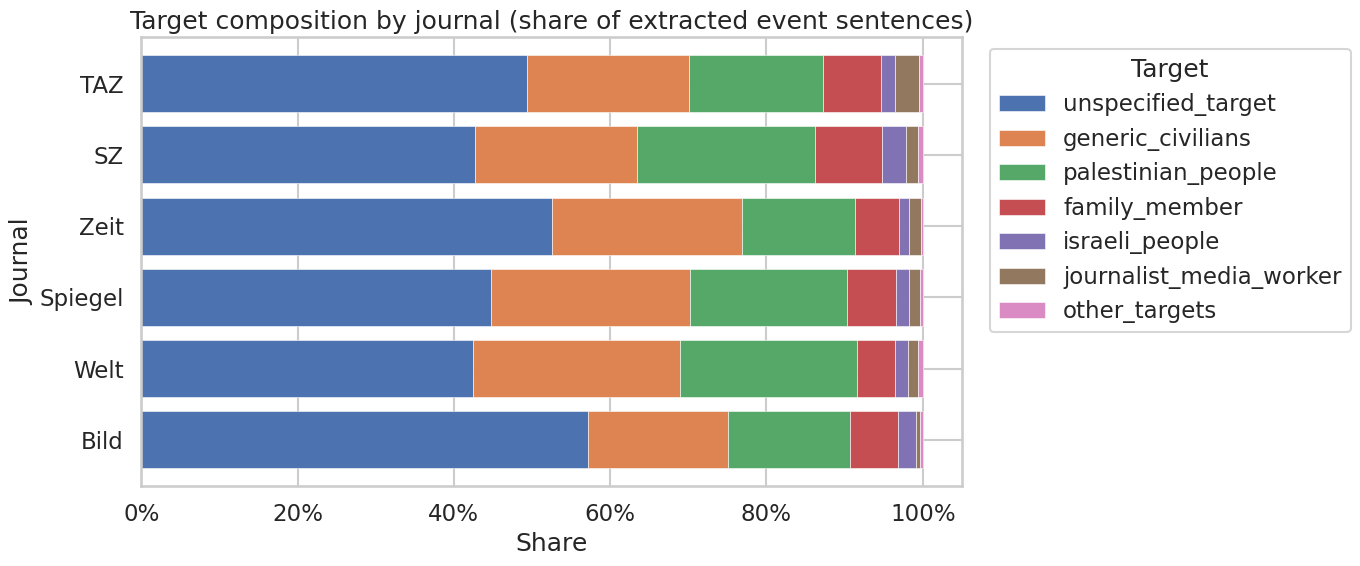

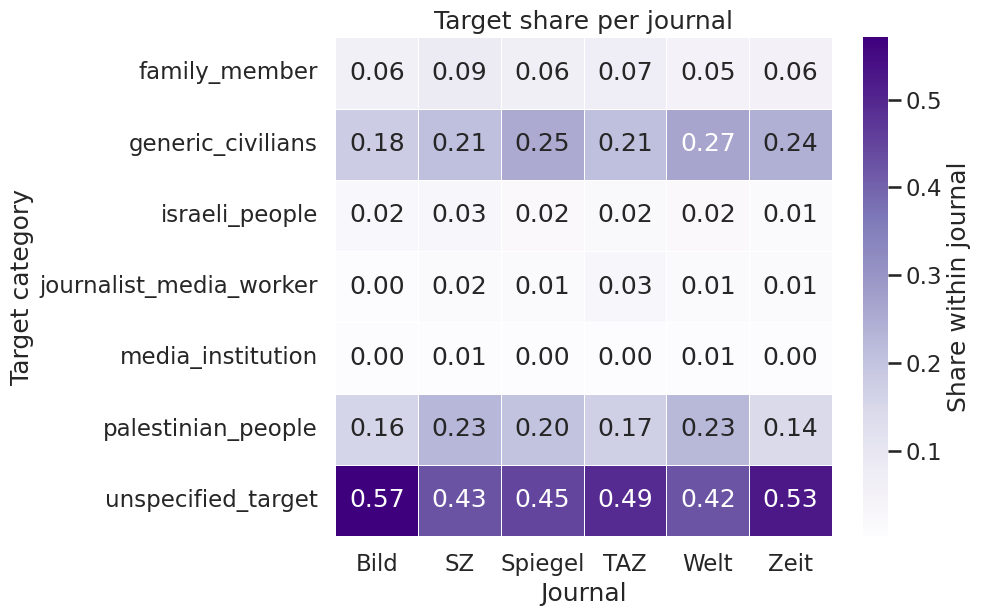

In [20]:
# --- Targets: summary + plots (ADJUSTED for audit_df) ---
# Assumes audit_df columns:
#   journal (str)
#   target  (str, possibly multiple labels separated by "; ")
#
# Produces:
#   - counts table
#   - shares table
#   - Plot 1: 100% stacked horizontal bars (readable)
#   - Plot 2: heatmap (kept similar, report-friendly)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid", context="talk")

def explode_str_labels(df, col, sep="; "):
    tmp = df[["journal", col]].copy()
    tmp[col] = tmp[col].fillna("").astype(str)
    tmp[col] = tmp[col].apply(lambda x: [p.strip() for p in x.split(sep) if p.strip()] if x else [])
    return (
        tmp.explode(col)
           .query(f"{col} != ''")
           .groupby(["journal", col]).size()
           .rename("n")
           .reset_index()
    )

# ---------------------------
# Counts + shares
# ---------------------------
target_counts = explode_str_labels(audit_df, "target")
target_mat = target_counts.pivot(index="journal", columns="target", values="n").fillna(0)

print("Target counts by journal:")
display(target_mat.astype(int))

target_share = target_mat.div(target_mat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
print("Target shares within journal:")
display((target_share * 100).round(2))

# ---------------------------
# Plot 1: 100% stacked HORIZONTAL bars (composition; much more readable)
# ---------------------------
top_k = 6
top_targets = target_mat.sum(axis=0).sort_values(ascending=False).head(top_k).index.tolist()

target_share_plot = target_share.copy()
other_cols = [c for c in target_share_plot.columns if c not in top_targets]
if other_cols:
    target_share_plot["other_targets"] = target_share_plot[other_cols].sum(axis=1)
    target_share_plot = target_share_plot[top_targets + ["other_targets"]]
else:
    target_share_plot = target_share_plot[top_targets]

# sort journals by share of "journalist_media_worker" if present (optional, helps comparison)
sort_key = "journalist_media_worker"
if sort_key in target_share_plot.columns:
    target_share_plot = target_share_plot.sort_values(sort_key, ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
target_share_plot.plot(
    kind="barh", stacked=True, ax=ax, width=0.8,
    edgecolor="white", linewidth=0.4
)
ax.set_title("Target composition by journal (share of extracted event sentences)")
ax.set_xlabel("Share")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("Journal")
ax.invert_yaxis()

ax.legend(title="Target", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

# ---------------------------
# Plot 2: Heatmap (kept similar; rows=target categories)
# ---------------------------
plt.figure(figsize=(10, 0.5 * len(target_share.columns) + 3))
sns.heatmap(
    target_share.T, annot=True, fmt=".2f", cmap="Purples",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Share within journal"}
)
plt.title("Target share per journal")
plt.xlabel("Journal")
plt.ylabel("Target category")
plt.tight_layout()
plt.show()